In [1]:
import numpy as np
import pandas as pd
import joblib

import matplotlib.pyplot as plt
import matplotlib.axes as ax
import seaborn as sns



from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression


sns.set_theme()

import warnings
warnings.filterwarnings("ignore")



In [2]:
df_purchase = pd.read_csv("../data/purchase_data.csv")

scaler = joblib.load("../models/scaler_model.pkl")
pca = joblib.load("../models/pca_model.pkl")
kmeans_pca = joblib.load("../models/kmeans_pca_model.pkl")

In [3]:
features = df_purchase[['Sex', 'Marital status', 'Age', 'Education', 'Income', 'Occupation', 'Settlement size']]
df_purchase_segm_std = scaler.transform(features)

In [4]:
# # Check for problematic values (numpy array syntax)
# print("NaN values:", np.isnan(df_purchase_segm_std).sum())
# print("Infinity values:", np.isinf(df_purchase_segm_std).sum())
# print("Data range:", np.nanmin(df_purchase_segm_std), "to", np.nanmax(df_purchase_segm_std))
# print("Shape:", df_purchase_segm_std.shape)
# print("\nFirst few rows:")
# print(df_purchase_segm_std[:5])

In [5]:
df_purchase_segm_pca = pca.transform(df_purchase_segm_std)

In [6]:
purchase_segm_kmeans_pca = kmeans_pca.predict(df_purchase_segm_pca)

In [7]:
df_purchase_predictors = df_purchase.copy()

In [8]:
df_purchase_predictors['Segment'] = purchase_segm_kmeans_pca
segment_dummies = pd.get_dummies(purchase_segm_kmeans_pca, prefix = 'Segment', prefix_sep= '_')
df_purchase_predictors = pd.concat([df_purchase_predictors, segment_dummies], axis=1)

In [9]:
df_pa = df_purchase_predictors

In [10]:
Y = df_pa['Incidence']

In [11]:
X = pd.DataFrame()

In [12]:
X['Mean_Price'] = (df_pa['Price_1'] +
                   df_pa['Price_2'] +
                   df_pa['Price_3'] +
                   df_pa['Price_4'] +
                   df_pa['Price_5']) / 5

In [13]:
model_purchase = LogisticRegression(solver = 'sag')
model_purchase.fit(X, Y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'sag'
,max_iter,100
,multi_class,'deprecated'


In [14]:
model_purchase.coef_

array([[-2.34811523]])

In [15]:
df_pa[['Price_1', 'Price_2', 'Price_3', 'Price_4', 'Price_5']].describe()

,Price_1,Price_2,Price_3,Price_4,Price_5
count,58693.000000,58693.000000,58693.000000,58693.000000,58693.000000
mean,1.392074,1.780999,2.006789,2.159945,2.654798
std,0.091139,0.170868,0.046867,0.089825,0.098272
min,1.100000,1.260000,1.870000,1.760000,2.110000
25%,1.340000,1.580000,1.970000,2.120000,2.630000
50%,1.390000,1.880000,2.010000,2.170000,2.670000
75%,1.470000,1.890000,2.060000,2.240000,2.700000
max,1.590000,1.900000,2.140000,2.260000,2.800000


In [16]:
price_range = np.arange(0.5,3.5,0.01)
price_range

array([0.5 , 0.51, 0.52, 0.53, 0.54, 0.55, 0.56, 0.57, 0.58, 0.59, 0.6 ,
       0.61, 0.62, 0.63, 0.64, 0.65, 0.66, 0.67, 0.68, 0.69, 0.7 , 0.71,
       0.72, 0.73, 0.74, 0.75, 0.76, 0.77, 0.78, 0.79, 0.8 , 0.81, 0.82,
       0.83, 0.84, 0.85, 0.86, 0.87, 0.88, 0.89, 0.9 , 0.91, 0.92, 0.93,
       0.94, 0.95, 0.96, 0.97, 0.98, 0.99, 1.  , 1.01, 1.02, 1.03, 1.04,
       1.05, 1.06, 1.07, 1.08, 1.09, 1.1 , 1.11, 1.12, 1.13, 1.14, 1.15,
       1.16, 1.17, 1.18, 1.19, 1.2 , 1.21, 1.22, 1.23, 1.24, 1.25, 1.26,
       1.27, 1.28, 1.29, 1.3 , 1.31, 1.32, 1.33, 1.34, 1.35, 1.36, 1.37,
       1.38, 1.39, 1.4 , 1.41, 1.42, 1.43, 1.44, 1.45, 1.46, 1.47, 1.48,
       1.49, 1.5 , 1.51, 1.52, 1.53, 1.54, 1.55, 1.56, 1.57, 1.58, 1.59,
       1.6 , 1.61, 1.62, 1.63, 1.64, 1.65, 1.66, 1.67, 1.68, 1.69, 1.7 ,
       1.71, 1.72, 1.73, 1.74, 1.75, 1.76, 1.77, 1.78, 1.79, 1.8 , 1.81,
       1.82, 1.83, 1.84, 1.85, 1.86, 1.87, 1.88, 1.89, 1.9 , 1.91, 1.92,
       1.93, 1.94, 1.95, 1.96, 1.97, 1.98, 1.99, 2.

In [17]:
df_price_range = pd.DataFrame(price_range)

In [18]:
Y_pr = model_purchase.predict_proba(df_price_range)
Y_pr

array([[0.08213975, 0.91786025],
       [0.08392752, 0.91607248],
       [0.08575056, 0.91424944],
       [0.08760942, 0.91239058],
       [0.08950462, 0.91049538],
       [0.09143672, 0.90856328],
       [0.09340625, 0.90659375],
       [0.09541374, 0.90458626],
       [0.09745974, 0.90254026],
       [0.09954479, 0.90045521],
       [0.10166942, 0.89833058],
       [0.10383416, 0.89616584],
       [0.10603956, 0.89396044],
       [0.10828614, 0.89171386],
       [0.11057443, 0.88942557],
       [0.11290495, 0.88709505],
       [0.11527822, 0.88472178],
       [0.11769476, 0.88230524],
       [0.12015508, 0.87984492],
       [0.12265968, 0.87734032],
       [0.12520906, 0.87479094],
       [0.12780371, 0.87219629],
       [0.13044411, 0.86955589],
       [0.13313073, 0.86686927],
       [0.13586403, 0.86413597],
       [0.13864449, 0.86135551],
       [0.14147252, 0.85852748],
       [0.14434858, 0.85565142],
       [0.14727307, 0.85272693],
       [0.15024641, 0.84975359],
       [0.

In [19]:
purchase_pr = Y_pr[:][:, 1]

In [20]:
pe = model_purchase.coef_[:, 0] * price_range * (1 - purchase_pr)

In [21]:
df_price_elasticities = pd.DataFrame(price_range)

In [22]:
df_price_elasticities = df_price_elasticities.rename(columns = {0: "Price_Point"})
df_price_elasticities['Mean_PE'] = pe
df_price_elasticities

,Price_Point,Mean_PE
0,0.50,-0.096437
1,0.51,-0.100506
2,0.52,-0.104703
3,0.53,-0.109030
4,0.54,-0.113490
...,...,...
295,3.45,-8.013157
296,3.46,-8.038406
297,3.47,-8.063621
298,3.48,-8.088803


Text(0.5, 1.0, 'Price Elasticity of Purchase Probablity')

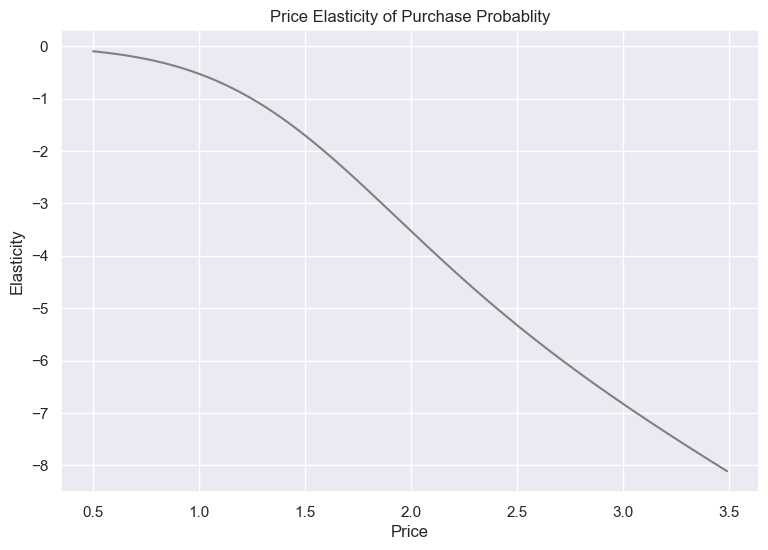

In [23]:
plt.figure(figsize = (9, 6))
plt.plot(price_range, pe, color = 'grey')
plt.xlabel('Price')
plt.ylabel('Elasticity')
plt.title('Price Elasticity of Purchase Probablity')

#### Purchase Probability by Segments ### 

In [24]:
### Segment 1 - Career-Focused
df_pa_segment_1 = df_pa[df_pa['Segment'] == 2]

In [25]:
Y = df_pa_segment_1['Incidence']

In [26]:
X = pd.DataFrame()

In [27]:
X['Mean_Price'] = (df_pa_segment_1['Price_1'] +
                   df_pa_segment_1['Price_2'] +
                   df_pa_segment_1['Price_3'] +
                   df_pa_segment_1['Price_4'] +
                   df_pa_segment_1['Price_5']) / 5

In [28]:
model_incidence_segment_1 = LogisticRegression(solver='sag')
model_incidence_segment_1.fit(X, Y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'sag'
,max_iter,100
,multi_class,'deprecated'


In [29]:
model_incidence_segment_1.coef_

array([[-1.70107608]])

In [30]:
Y_segment_1 = model_incidence_segment_1.predict_proba(df_price_range)
purchase_pr_segment_1 = Y_segment_1[:][:, 1]
pe_segment_1 = model_incidence_segment_1.coef_[:, 0] * price_range * ( 1 - purchase_pr_segment_1)

In [31]:
df_price_elasticities['PE_Segment_1'] = pe_segment_1
df_price_elasticities

,Price_Point,Mean_PE,PE_Segment_1
0,0.50,-0.096437,-0.177530
1,0.51,-0.100506,-0.183530
2,0.52,-0.104703,-0.189651
3,0.53,-0.109030,-0.195894
4,0.54,-0.113490,-0.202260
...,...,...,...
295,3.45,-8.013157,-5.725109
296,3.46,-8.038406,-5.744074
297,3.47,-8.063621,-5.763015
298,3.48,-8.088803,-5.781931


Text(0.5, 1.0, 'Price Elasticity of Purchase Probability')

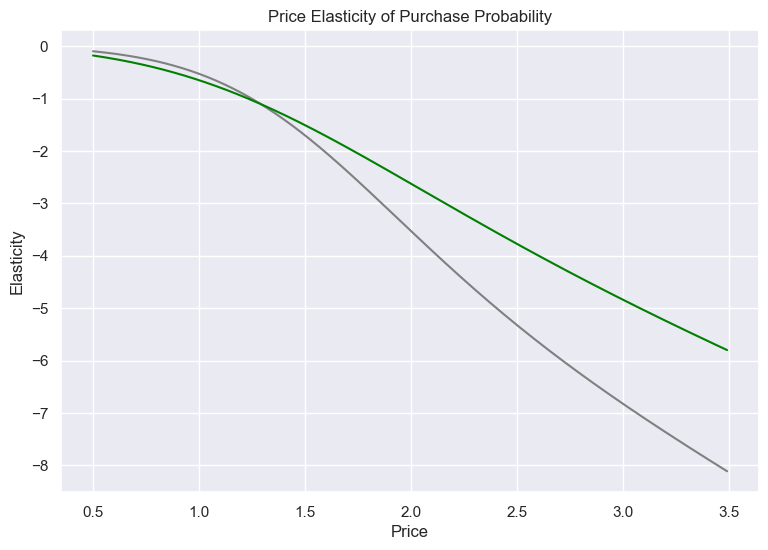

In [32]:
plt.figure(figsize = (9, 6))
plt.plot(price_range, pe, color = 'grey')
plt.plot(price_range, pe_segment_1, color = 'green')
plt.xlabel('Price')
plt.ylabel('Elasticity')
plt.title('Price Elasticity of Purchase Probability')

### Segment 2 - Fewer-opportunities ###

In [33]:
df_pa_segment_2 = df_pa[df_pa['Segment'] == 1]


In [34]:
Y = df_pa_segment_2['Incidence']

In [35]:
X = pd.DataFrame()

In [36]:
X['Mean_Price'] = (df_pa_segment_2['Price_1'] +
                   df_pa_segment_2['Price_2'] +
                   df_pa_segment_2['Price_3'] +
                   df_pa_segment_2['Price_4'] +
                   df_pa_segment_2['Price_5']) / 5

In [37]:
model_incidence_segment_2 = LogisticRegression(solver = 'sag')
model_incidence_segment_2.fit(X,Y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'sag'
,max_iter,100
,multi_class,'deprecated'


In [38]:
model_incidence_segment_2.coef_
Y_segment_2 = model_incidence_segment_2.predict_proba(df_price_range)
purchase_pr_segment2 = Y_segment_2[:][: , 1]
pe_segment2 = model_incidence_segment_2.coef_[:,0] * price_range * (1 - purchase_pr_segment2)

In [39]:
df_price_elasticities['PE_Segment2'] = pe_segment2

In [40]:
df_price_elasticities

,Price_Point,Mean_PE,PE_Segment_1,PE_Segment2
0,0.50,-0.096437,-0.177530,-0.095463
1,0.51,-0.100506,-0.183530,-0.099774
2,0.52,-0.104703,-0.189651,-0.104234
3,0.53,-0.109030,-0.195894,-0.108849
4,0.54,-0.113490,-0.202260,-0.113621
...,...,...,...,...
295,3.45,-8.013157,-5.725109,-9.023126
296,3.46,-8.038406,-5.744074,-9.050556
297,3.47,-8.063621,-5.763015,-9.077960
298,3.48,-8.088803,-5.781931,-9.105340


Text(0.5, 1.0, 'Price Elasticity of Purchase Probability')

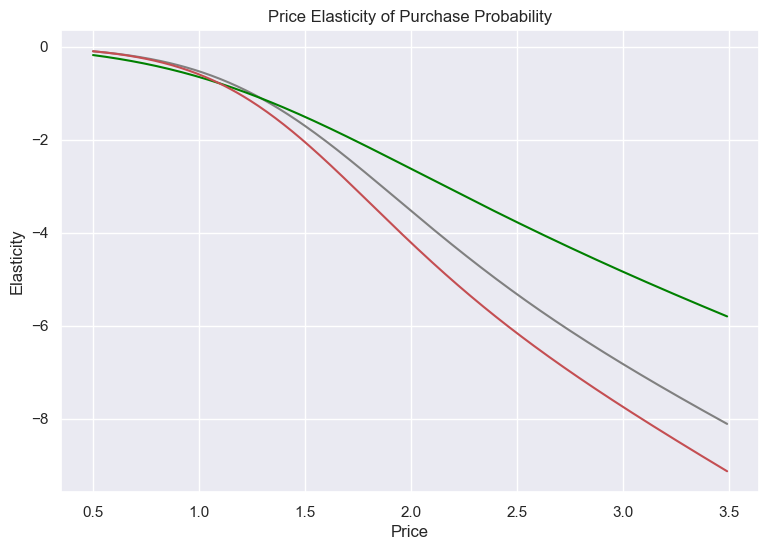

In [41]:
plt.figure(figsize = (9, 6))
plt.plot(price_range, pe, color = 'grey')
plt.plot(price_range, pe_segment_1, color = 'green')
plt.plot(price_range, pe_segment2, color = 'r')
plt.xlabel('Price')
plt.ylabel('Elasticity')
plt.title('Price Elasticity of Purchase Probability')

In [42]:
df_pa_segment_0 = df_pa[df_pa['Segment'] == 0]

Y = df_pa_segment_0['Incidence']

X = pd.DataFrame()
X['Mean_Price'] = (df_pa_segment_0['Price_1'] +
                   df_pa_segment_0['Price_2'] +
                   df_pa_segment_0['Price_3'] +
                   df_pa_segment_0['Price_4'] +
                   df_pa_segment_0['Price_5']) / 5

model_incidence_segment0 = LogisticRegression(solver = 'sag')
model_incidence_segment0.fit(X, Y)

model_incidence_segment0.coef_
Y_segment_0 = model_incidence_segment0.predict_proba(df_price_range)
purchase_pr_segment0 = Y_segment_0[:][: , 1]
pe_segment0 = model_incidence_segment0.coef_[:,0] * price_range *( 1- purchase_pr_segment0)
df_price_elasticities.insert(2, column = 'PE_Segment_0', value = pe_segment0)

In [43]:
df_pa_segment_3 = df_pa[df_pa['Segment'] == 3]

Y = df_pa_segment_3['Incidence']

X = pd.DataFrame()
X['Mean_Price'] = (df_pa_segment_3['Price_1'] +
                   df_pa_segment_3['Price_2'] +
                   df_pa_segment_3['Price_3'] +
                   df_pa_segment_3['Price_4'] +
                   df_pa_segment_3['Price_5']) / 5

model_incidence_segment3 = LogisticRegression(solver = 'sag')
model_incidence_segment3.fit(X, Y)

model_incidence_segment3.coef_
Y_segment_3 = model_incidence_segment3.predict_proba(df_price_range)
purchase_pr_segment3 = Y_segment_3[:][: , 1]
pe_segment3 = model_incidence_segment3.coef_[:,0] * price_range *( 1- purchase_pr_segment3)
df_price_elasticities['PE_Segment_3'] = pe_segment3
df_price_elasticities

,Price_Point,Mean_PE,PE_Segment_0,PE_Segment_1,PE_Segment2,PE_Segment_3
0,0.50,-0.096437,-0.068897,-0.177530,-0.095463,-0.159093
1,0.51,-0.100506,-0.071950,-0.183530,-0.099774,-0.164047
2,0.52,-0.104703,-0.075107,-0.189651,-0.104234,-0.169084
3,0.53,-0.109030,-0.078370,-0.195894,-0.108849,-0.174206
4,0.54,-0.113490,-0.081743,-0.202260,-0.113621,-0.179413
...,...,...,...,...,...,...
295,3.45,-8.013157,-8.514278,-5.725109,-9.023126,-4.602608
296,3.46,-8.038406,-8.541223,-5.744074,-9.050556,-4.619253
297,3.47,-8.063621,-8.568127,-5.763015,-9.077960,-4.635876
298,3.48,-8.088803,-8.594990,-5.781931,-9.105340,-4.652477


Text(0.5, 1.0, 'Price Elasticity of Purchase Probability')

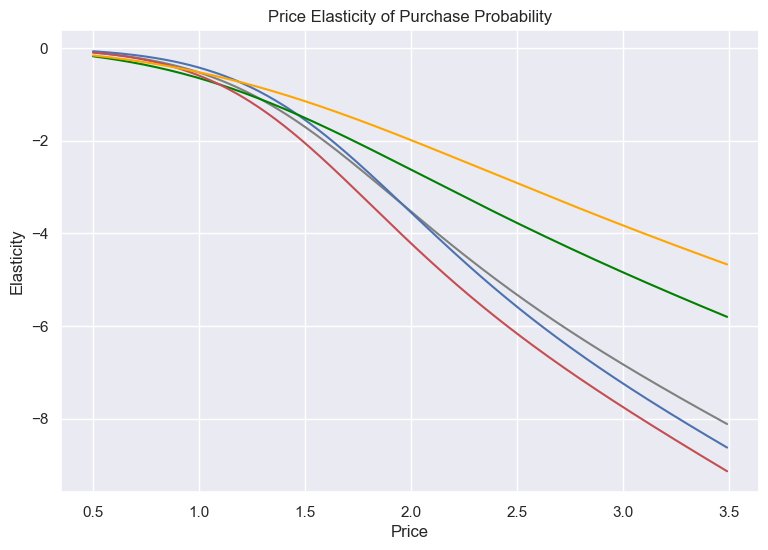

In [44]:
plt.figure(figsize = (9, 6))
plt.plot(price_range, pe, color = 'grey')
plt.plot(price_range, pe_segment0, color = 'b')
plt.plot(price_range, pe_segment_1, color = 'green')
plt.plot(price_range, pe_segment2, color = 'r')
plt.plot(price_range, pe_segment3, color = 'orange')
plt.xlabel('Price')
plt.ylabel('Elasticity')
plt.title('Price Elasticity of Purchase Probability')

### Purchase Probability with Promotion Feature #### 

In [45]:
#Data Prpartion
Y = df_pa['Incidence']

In [46]:
X = pd.DataFrame()

X['Mean_Price'] = (df_pa['Price_1'] +
                   df_pa['Price_2'] +
                   df_pa['Price_3'] +
                   df_pa['Price_4'] +
                   df_pa['Price_5']) / 5

In [47]:
X['Mean_Promotion'] = (df_pa['Promotion_1'] +
                   df_pa['Promotion_2'] +
                   df_pa['Promotion_3'] +
                   df_pa['Promotion_4'] +
                   df_pa['Promotion_5']) / 5
X

,Mean_Price,Mean_Promotion
0,2.044,0.2
1,2.028,0.0
2,2.028,0.0
3,2.028,0.0
4,2.030,0.0
...,...,...
58688,2.060,0.2
58689,2.060,0.0
58690,2.086,0.0
58691,2.092,0.0


In [48]:
model_incidence_promotion = LogisticRegression(solver = 'sag')
model_incidence_promotion.fit(X, Y)
model_incidence_promotion.coef_

array([[-1.49394886,  0.56152849]])

In [49]:
df_price_elasticity_promotion = pd.DataFrame(price_range)
df_price_elasticity_promotion = df_price_elasticity_promotion.rename(columns = {0: "Mean_Price"})

In [50]:
df_price_elasticity_promotion['Mean_Promotion'] = 1

In [51]:
Y_promotion = model_incidence_promotion.predict_proba(df_price_elasticity_promotion)

In [52]:
promo = Y_promotion[:, 1]
price_elasticity_promo = (model_incidence_promotion.coef_[:, 0] * price_range) * (1 - promo)

In [53]:
df_price_elasticities['Elasticity_Promotion_1'] = price_elasticity_promo
df_price_elasticities

,Price_Point,Mean_PE,PE_Segment_0,PE_Segment_1,PE_Segment2,PE_Segment_3,Elasticity_Promotion_1
0,0.50,-0.096437,-0.068897,-0.177530,-0.095463,-0.159093,-0.125715
1,0.51,-0.100506,-0.071950,-0.183530,-0.099774,-0.164047,-0.129830
2,0.52,-0.104703,-0.075107,-0.189651,-0.104234,-0.169084,-0.134025
3,0.53,-0.109030,-0.078370,-0.195894,-0.108849,-0.174206,-0.138299
4,0.54,-0.113490,-0.081743,-0.202260,-0.113621,-0.179413,-0.142655
...,...,...,...,...,...,...,...
295,3.45,-8.013157,-8.514278,-5.725109,-9.023126,-4.602608,-4.861280
296,3.46,-8.038406,-8.541223,-5.744074,-9.050556,-4.619253,-4.879481
297,3.47,-8.063621,-8.568127,-5.763015,-9.077960,-4.635876,-4.897652
298,3.48,-8.088803,-8.594990,-5.781931,-9.105340,-4.652477,-4.915793


In [54]:
df_price_elasticity_promotion_no = pd.DataFrame(price_range)
df_price_elasticity_promotion_no = df_price_elasticity_promotion_no.rename(columns = {0: "Mean_Price"})

In [55]:
df_price_elasticity_promotion_no['Mean_Promotion'] = 0

In [56]:
Y_no_promo = model_incidence_promotion.predict_proba(df_price_elasticity_promotion_no)

In [57]:
no_promo = Y_no_promo[: , 1]

In [58]:
price_elasticity_no_promo = model_incidence_promotion.coef_[:, 0] * price_range *(1- no_promo)

In [59]:
df_price_elasticities['Elasticity_Promotion_0'] = price_elasticity_no_promo

Text(0.5, 1.0, 'Price Elasticity of Purchase Probability with and without Promotion')

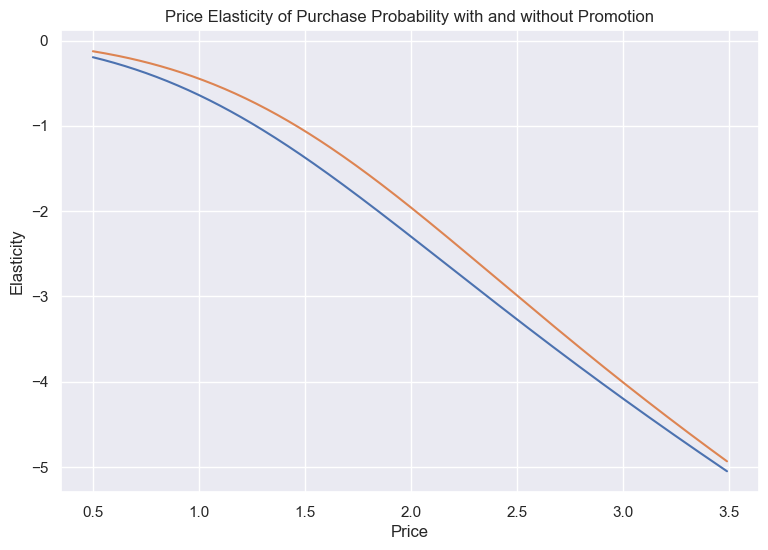

In [60]:
plt.figure(figsize = (9, 6))
plt.plot(price_range, price_elasticity_no_promo)
plt.plot(price_range, price_elasticity_promo)
plt.xlabel('Price')
plt.ylabel('Elasticity')
plt.title('Price Elasticity of Purchase Probability with and without Promotion')

In [61]:
### Brand Choice
brand_choice = df_pa[df_pa['Incidence'] == 1]

In [62]:
brand_choice

,ID,Day,Incidence,Brand,Quantity,Last_Inc_Brand,Last_Inc_Quantity,Price_1,Price_2,Price_3,...,Age,Education,Income,Occupation,Settlement size,Segment,Segment_0,Segment_1,Segment_2,Segment_3
6,200000001,28,1,2,2,0,0,1.50,1.90,1.99,...,47,1,110866,1,0,0,True,False,False,False
11,200000001,58,1,5,1,0,0,1.39,1.90,1.91,...,47,1,110866,1,0,0,True,False,False,False
19,200000001,110,1,1,2,0,0,1.47,1.90,1.99,...,47,1,110866,1,0,0,True,False,False,False
24,200000001,142,1,4,1,0,0,1.21,1.35,1.99,...,47,1,110866,1,0,0,True,False,False,False
29,200000001,183,1,2,3,0,0,1.46,1.88,1.97,...,47,1,110866,1,0,0,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58621,200000500,296,1,2,6,0,0,1.48,1.89,2.01,...,42,1,120946,1,0,0,True,False,False,False
58648,200000500,460,1,1,12,0,0,1.35,1.57,2.02,...,42,1,120946,1,0,0,True,False,False,False
58674,200000500,641,1,2,7,0,0,1.50,1.85,2.06,...,42,1,120946,1,0,0,True,False,False,False
58687,200000500,697,1,2,6,0,0,1.42,1.51,1.97,...,42,1,120946,1,0,0,True,False,False,False


In [63]:
Y = brand_choice['Brand']

In [64]:
brand_choice.columns.values

array(['ID', 'Day', 'Incidence', 'Brand', 'Quantity', 'Last_Inc_Brand',
       'Last_Inc_Quantity', 'Price_1', 'Price_2', 'Price_3', 'Price_4',
       'Price_5', 'Promotion_1', 'Promotion_2', 'Promotion_3',
       'Promotion_4', 'Promotion_5', 'Sex', 'Marital status', 'Age',
       'Education', 'Income', 'Occupation', 'Settlement size', 'Segment',
       'Segment_0', 'Segment_1', 'Segment_2', 'Segment_3'], dtype=object)

In [65]:
features = ["Price_1", "Price_2", "Price_3", "Price_4", "Price_5"]
X = brand_choice[features]

In [66]:
model_brand_choice = LogisticRegression(solver = 'sag', multi_class='multinomial')
model_brand_choice.fit(X,Y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'sag'
,max_iter,100
,multi_class,'multinomial'


In [67]:
model_brand_choice.coef_

array([[-3.91594267,  0.6584656 ,  2.41778272,  0.70409394, -0.20209099],
       [ 1.27461386, -1.87985409, -0.21263637, -0.20633852,  0.5878723 ],
       [ 1.62416846,  0.56209887,  0.50079453,  1.03949132,  0.45276337],
       [ 0.57453859,  0.39558972, -1.40059869, -1.24624141,  0.24935271],
       [ 0.44262177,  0.26369991, -1.30534219, -0.29100533, -1.08789739]])

In [68]:
bc_coef = pd.DataFrame(model_brand_choice.coef_)
bc_coef

,0,1,2,3,4
0,-3.915943,0.658466,2.417783,0.704094,-0.202091
1,1.274614,-1.879854,-0.212636,-0.206339,0.587872
2,1.624168,0.562099,0.500795,1.039491,0.452763
3,0.574539,0.395590,-1.400599,-1.246241,0.249353
4,0.442622,0.263700,-1.305342,-0.291005,-1.087897


In [69]:
bc_coef = pd.DataFrame(np.transpose(model_brand_choice.coef_))
coefficients = ["Coef_Brand_1", "Coef_Brand_2", "Coef_Brand_3", "Coef_Brand_4", "Coef_Brand_5"]
bc_coef.columns = coefficients
prices = ['Price_1', 'Price_2', 'Price_3', 'Price_4', 'Price_5']
bc_coef.index = prices
bc_coef = bc_coef.round(2)
bc_coef

,Coef_Brand_1,Coef_Brand_2,Coef_Brand_3,Coef_Brand_4,Coef_Brand_5
Price_1,-3.92,1.27,1.62,0.57,0.44
Price_2,0.66,-1.88,0.56,0.40,0.26
Price_3,2.42,-0.21,0.50,-1.40,-1.31
Price_4,0.70,-0.21,1.04,-1.25,-0.29
Price_5,-0.20,0.59,0.45,0.25,-1.09


In [70]:
df_own_brand_5 = pd.DataFrame(index = np.arange(price_range.size))
df_own_brand_5['Price_1'] = brand_choice['Price_1'].mean()
df_own_brand_5['Price_2'] = brand_choice['Price_2'].mean()
df_own_brand_5['Price_3'] = brand_choice['Price_3'].mean()
df_own_brand_5['Price_4'] = brand_choice['Price_4'].mean()
df_own_brand_5['Price_5'] = price_range
df_own_brand_5

,Price_1,Price_2,Price_3,Price_4,Price_5
0,1.384559,1.764717,2.006694,2.159658,0.50
1,1.384559,1.764717,2.006694,2.159658,0.51
2,1.384559,1.764717,2.006694,2.159658,0.52
3,1.384559,1.764717,2.006694,2.159658,0.53
4,1.384559,1.764717,2.006694,2.159658,0.54
...,...,...,...,...,...
295,1.384559,1.764717,2.006694,2.159658,3.45
296,1.384559,1.764717,2.006694,2.159658,3.46
297,1.384559,1.764717,2.006694,2.159658,3.47
298,1.384559,1.764717,2.006694,2.159658,3.48


In [71]:
predict_brand_5 = model_brand_choice.predict_proba(df_own_brand_5)

In [72]:
pr_own_brand_5 = predict_brand_5[:][:, 4]

In [73]:
beta5 = bc_coef.iloc[4, 4]
beta5

np.float64(-1.09)

In [74]:
own_price_elasticity_brand_5 = beta5 * price_range * (1 - pr_own_brand_5)

In [75]:
df_price_elasticities['Brand_5'] = own_price_elasticity_brand_5
df_price_elasticities

,Price_Point,Mean_PE,PE_Segment_0,PE_Segment_1,PE_Segment2,PE_Segment_3,Elasticity_Promotion_1,Elasticity_Promotion_0,Brand_5
0,0.50,-0.096437,-0.068897,-0.177530,-0.095463,-0.159093,-0.125715,-0.195620,-0.049055
1,0.51,-0.100506,-0.071950,-0.183530,-0.099774,-0.164047,-0.129830,-0.201741,-0.050616
2,0.52,-0.104703,-0.075107,-0.189651,-0.104234,-0.169084,-0.134025,-0.207964,-0.052206
3,0.53,-0.109030,-0.078370,-0.195894,-0.108849,-0.174206,-0.138299,-0.214290,-0.053826
4,0.54,-0.113490,-0.081743,-0.202260,-0.113621,-0.179413,-0.142655,-0.220720,-0.055477
...,...,...,...,...,...,...,...,...,...
295,3.45,-8.013157,-8.514278,-5.725109,-9.023126,-4.602608,-4.861280,-4.982925,-3.231573
296,3.46,-8.038406,-8.541223,-5.744074,-9.050556,-4.619253,-4.879481,-4.999830,-3.247767
297,3.47,-8.063621,-8.568127,-5.763015,-9.077960,-4.635876,-4.897652,-5.016716,-3.263929
298,3.48,-8.088803,-8.594990,-5.781931,-9.105340,-4.652477,-4.915793,-5.033582,-3.280058


Text(0.5, 1.0, 'Own Price Elasticity of Purchase Probability for Brand 5')

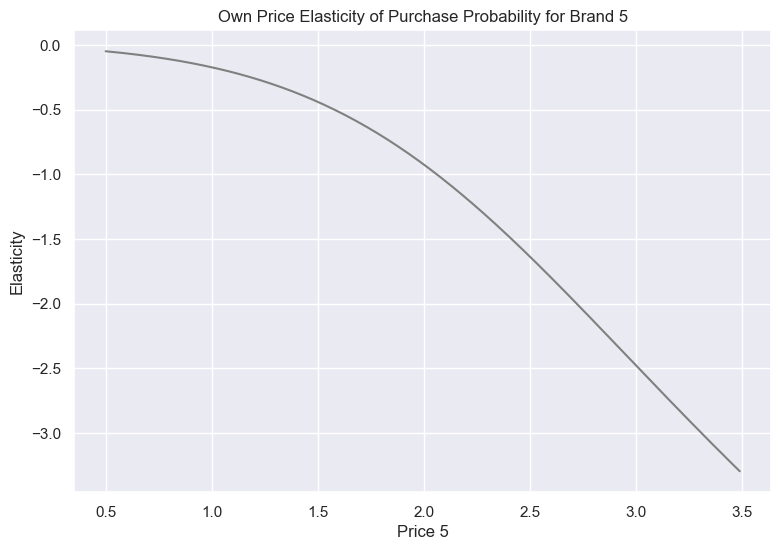

In [76]:
plt.figure(figsize = (9, 6))
plt.plot(price_range, own_price_elasticity_brand_5, color = 'grey')
plt.xlabel('Price 5')
plt.ylabel('Elasticity')
plt.title('Own Price Elasticity of Purchase Probability for Brand 5')

In [77]:
### Cross-Price Elasticity for Brand 5, Cross Brand 4
df_brand5_cross_brand4 = pd.DataFrame(index = np.arange(price_range.size))
df_brand5_cross_brand4['Price_1'] = brand_choice['Price_1'].mean()
df_brand5_cross_brand4['Price_2'] = brand_choice['Price_2'].mean()
df_brand5_cross_brand4['Price_3'] = brand_choice['Price_3'].mean()
df_brand5_cross_brand4['Price_4'] = price_range
df_brand5_cross_brand4['Price_5'] = brand_choice['Price_5'].mean()

df_brand5_cross_brand4.head()

,Price_1,Price_2,Price_3,Price_4,Price_5
0,1.384559,1.764717,2.006694,0.50,2.654296
1,1.384559,1.764717,2.006694,0.51,2.654296
2,1.384559,1.764717,2.006694,0.52,2.654296
3,1.384559,1.764717,2.006694,0.53,2.654296
4,1.384559,1.764717,2.006694,0.54,2.654296


In [78]:
predict_brand5_cross_brand4 = model_brand_choice.predict_proba(df_brand5_cross_brand4)

In [79]:
pr_brand_4 = predict_brand5_cross_brand4[:][:, 3]

In [80]:
beta5

np.float64(-1.09)

In [81]:
brand5_cross_brand4_price_elasticity = -beta5 * price_range * pr_brand_4

In [82]:
df_price_elasticities['Brand_5_Cross_Brand_4'] = brand5_cross_brand4_price_elasticity
df_price_elasticities

,Price_Point,Mean_PE,PE_Segment_0,PE_Segment_1,PE_Segment2,PE_Segment_3,Elasticity_Promotion_1,Elasticity_Promotion_0,Brand_5,Brand_5_Cross_Brand_4
0,0.50,-0.096437,-0.068897,-0.177530,-0.095463,-0.159093,-0.125715,-0.195620,-0.049055,0.332011
1,0.51,-0.100506,-0.071950,-0.183530,-0.099774,-0.164047,-0.129830,-0.201741,-0.050616,0.337287
2,0.52,-0.104703,-0.075107,-0.189651,-0.104234,-0.169084,-0.134025,-0.207964,-0.052206,0.342506
3,0.53,-0.109030,-0.078370,-0.195894,-0.108849,-0.174206,-0.138299,-0.214290,-0.053826,0.347668
4,0.54,-0.113490,-0.081743,-0.202260,-0.113621,-0.179413,-0.142655,-0.220720,-0.055477,0.352773
...,...,...,...,...,...,...,...,...,...,...
295,3.45,-8.013157,-8.514278,-5.725109,-9.023126,-4.602608,-4.861280,-4.982925,-3.231573,0.162233
296,3.46,-8.038406,-8.541223,-5.744074,-9.050556,-4.619253,-4.879481,-4.999830,-3.247767,0.160333
297,3.47,-8.063621,-8.568127,-5.763015,-9.077960,-4.635876,-4.897652,-5.016716,-3.263929,0.158447
298,3.48,-8.088803,-8.594990,-5.781931,-9.105340,-4.652477,-4.915793,-5.033582,-3.280058,0.156576


Text(0.5, 1.0, 'Cross Price Elasticity of Brand 5 wrt to Brand 4')

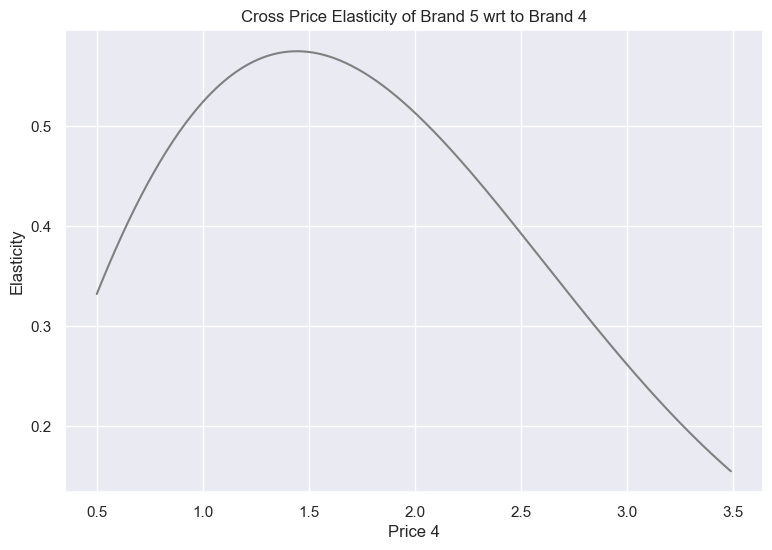

In [83]:
plt.figure(figsize = (9, 6))
plt.plot(price_range, brand5_cross_brand4_price_elasticity, color = 'grey')
plt.xlabel('Price 4')
plt.ylabel('Elasticity')
plt.title('Cross Price Elasticity of Brand 5 wrt to Brand 4')

In [84]:
### Well-off
brand_choice_s3 = df_pa[df_pa['Incidence'] == 1]
brand_choice_s3 = brand_choice_s3[brand_choice_s3['Segment'] == 3]

pd.options.display.max_rows = 100
brand_choice_s3

,ID,Day,Incidence,Brand,Quantity,Last_Inc_Brand,Last_Inc_Quantity,Price_1,Price_2,Price_3,...,Age,Education,Income,Occupation,Settlement size,Segment,Segment_0,Segment_1,Segment_2,Segment_3
101,200000002,6,1,4,1,0,0,1.59,1.87,2.01,...,52,2,159052,2,1,3,False,False,False,True
115,200000002,100,1,4,2,0,0,1.47,1.90,1.95,...,52,2,159052,2,1,3,False,False,False,True
138,200000002,283,1,4,3,0,0,1.37,1.89,2.00,...,52,2,159052,2,1,3,False,False,False,True
141,200000002,307,1,4,1,0,0,1.34,1.89,2.01,...,52,2,159052,2,1,3,False,False,False,True
153,200000002,422,1,4,1,0,0,1.34,1.89,2.02,...,52,2,159052,2,1,3,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57346,200000489,687,1,4,1,4,1,1.50,1.87,2.06,...,44,2,193816,2,1,3,False,False,False,True
57347,200000489,693,1,4,2,4,1,1.42,1.51,2.02,...,44,2,193816,2,1,3,False,False,False,True
57348,200000489,701,1,4,3,4,1,1.42,1.85,1.99,...,44,2,193816,2,1,3,False,False,False,True
57350,200000489,715,1,4,2,0,0,1.50,1.80,2.09,...,44,2,193816,2,1,3,False,False,False,True


In [85]:
# model estimation
Y = brand_choice_s3['Brand']
brand_choice_s3 = pd.get_dummies(brand_choice_s3, columns=['Brand'], prefix = 'Brand', prefix_sep = '_')
X = brand_choice_s3[features]
model_brand_choice_s3 = LogisticRegression(solver = 'sag', multi_class = 'multinomial', max_iter = 300)
model_brand_choice_s3.fit(X, Y)

#coefficients table for segment 3
bc_coef = pd.DataFrame(np.transpose(model_brand_choice_s3.coef_))
bc_coef.columns = [coefficients]
bc_coef.index = [prices]
bc_coef = bc_coef.round(2)
bc_coef

,Coef_Brand_1,Coef_Brand_2,Coef_Brand_3,Coef_Brand_4,Coef_Brand_5
Price_1,-2.23,1.22,0.82,0.28,-0.08
Price_2,-0.94,-1.38,1.24,0.78,0.30
Price_3,1.94,-1.67,-0.40,-0.02,0.15
Price_4,2.55,0.58,-0.15,-1.74,-1.23
Price_5,-0.97,-0.36,1.19,0.54,-0.41


In [86]:
# own Brand Price Elasticity
df_own_brand_5_s3 = pd.DataFrame(index = np.arange(price_range.size))
df_own_brand_5_s3['Price_1'] = brand_choice_s3['Price_1'].mean()
df_own_brand_5_s3['Price_2'] = brand_choice_s3['Price_2'].mean()
df_own_brand_5_s3['Price_3'] = brand_choice_s3['Price_3'].mean()
df_own_brand_5_s3['Price_4'] = brand_choice_s3['Price_4'].mean()
df_own_brand_5_s3['Price_5'] = price_range

predict_own_brand_5_s3 = model_brand_choice_s3.predict_proba(df_own_brand_5_s3)
pr_own_brand_5_s3 = predict_own_brand_5_s3[: ][: , 4]

own_price_elasticity_brand_5_s3 =  beta5 * price_range * (1 - pr_own_brand_5_s3)
df_price_elasticities['Brand 5 S3'] = own_price_elasticity_brand_5_s3

In [87]:
### Cross-Brand Price Elasticity
df_brand5_cross_brand4_s3 = pd.DataFrame(index = np.arange(price_range.size))
df_brand5_cross_brand4_s3['Price_1'] = brand_choice_s3['Price_1'].mean()
df_brand5_cross_brand4_s3['Price_2'] = brand_choice_s3['Price_2'].mean()
df_brand5_cross_brand4_s3['Price_3'] = brand_choice_s3['Price_3'].mean()
df_brand5_cross_brand4_s3['Price_4'] = price_range
df_brand5_cross_brand4_s3['Price_5'] = brand_choice_s3['Price_5'].mean()

predict_brand5_cross_brand4_s3 = model_brand_choice_s3.predict_proba(df_brand5_cross_brand4_s3)
pr_cross_brand_5_s3 = predict_brand5_cross_brand4_s3[: ][: , 3]

brand5_cross_brand4_price_elasticity_s3 = -beta5 * price_range * pr_cross_brand_5_s3
df_price_elasticities['Brand_5_Cross_Brand_4_S3'] = brand5_cross_brand4_price_elasticity_s3
pd.options.display.max_rows = None
df_price_elasticities

,Price_Point,Mean_PE,PE_Segment_0,PE_Segment_1,PE_Segment2,PE_Segment_3,Elasticity_Promotion_1,Elasticity_Promotion_0,Brand_5,Brand_5_Cross_Brand_4,Brand 5 S3,Brand_5_Cross_Brand_4_S3
0,0.50,-0.096437,-0.068897,-0.177530,-0.095463,-0.159093,-0.125715,-0.195620,-0.049055,0.332011,-0.316398,0.474975
1,0.51,-0.100506,-0.071950,-0.183530,-0.099774,-0.164047,-0.129830,-0.201741,-0.050616,0.337287,-0.322783,0.484118
2,0.52,-0.104703,-0.075107,-0.189651,-0.104234,-0.169084,-0.134025,-0.207964,-0.052206,0.342506,-0.329176,0.493246
3,0.53,-0.109030,-0.078370,-0.195894,-0.108849,-0.174206,-0.138299,-0.214290,-0.053826,0.347668,-0.335577,0.502357
4,0.54,-0.113490,-0.081743,-0.202260,-0.113621,-0.179413,-0.142655,-0.220720,-0.055477,0.352773,-0.341986,0.511452
5,0.55,-0.118087,-0.085230,-0.208752,-0.118556,-0.184705,-0.147092,-0.227255,-0.057158,0.357820,-0.348404,0.520531
6,0.56,-0.122824,-0.088832,-0.215369,-0.123658,-0.190083,-0.151612,-0.233896,-0.058870,0.362809,-0.354832,0.529592
7,0.57,-0.127704,-0.092554,-0.222115,-0.128931,-0.195549,-0.156216,-0.240644,-0.060614,0.367740,-0.361268,0.538637
8,0.58,-0.132731,-0.096398,-0.228989,-0.134381,-0.201102,-0.160905,-0.247499,-0.062390,0.372614,-0.367715,0.547665
9,0.59,-0.137908,-0.100369,-0.235994,-0.140012,-0.206745,-0.165679,-0.254461,-0.064199,0.377429,-0.374171,0.556676


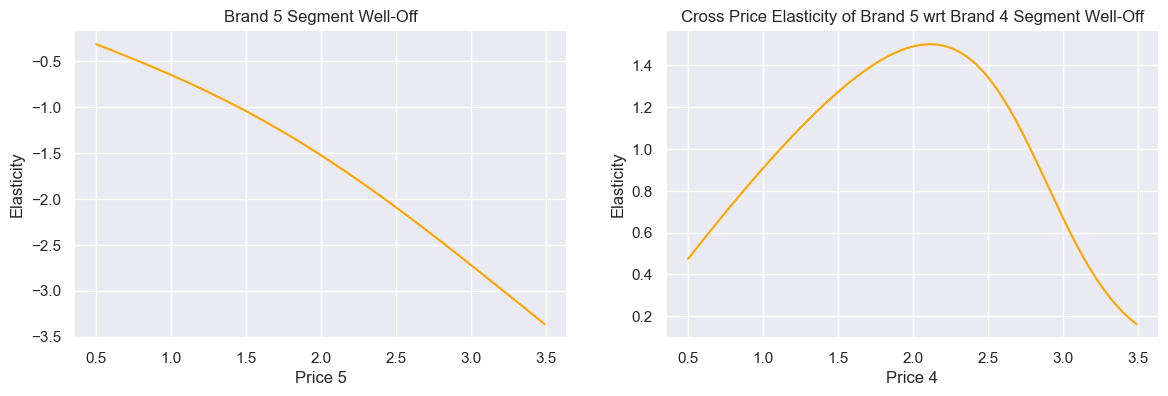

In [88]:
fig, axs = plt.subplots(1, 2, figsize = (14, 4))
axs[0].plot(price_range, own_price_elasticity_brand_5_s3, color = 'orange')
axs[0].set_title('Brand 5 Segment Well-Off')
axs[0].set_xlabel('Price 5')

axs[1].plot(price_range, brand5_cross_brand4_price_elasticity_s3, color = 'orange')
axs[1].set_title('Cross Price Elasticity of Brand 5 wrt Brand 4 Segment Well-Off')
axs[1].set_xlabel('Price 4')

for ax in axs.flat:
    ax.set(ylabel = 'Elasticity')

In [89]:
### Standard
brand_choice_s0 = df_pa[df_pa['Incidence'] == 1]
brand_choice_s0 = brand_choice_s0[brand_choice_s0['Segment'] == 0]
brand_choice_s0.head()

,ID,Day,Incidence,Brand,Quantity,Last_Inc_Brand,Last_Inc_Quantity,Price_1,Price_2,Price_3,...,Age,Education,Income,Occupation,Settlement size,Segment,Segment_0,Segment_1,Segment_2,Segment_3
6,200000001,28,1,2,2,0,0,1.50,1.90,1.99,...,47,1,110866,1,0,0,True,False,False,False
11,200000001,58,1,5,1,0,0,1.39,1.90,1.91,...,47,1,110866,1,0,0,True,False,False,False
19,200000001,110,1,1,2,0,0,1.47,1.90,1.99,...,47,1,110866,1,0,0,True,False,False,False
24,200000001,142,1,4,1,0,0,1.21,1.35,1.99,...,47,1,110866,1,0,0,True,False,False,False
29,200000001,183,1,2,3,0,0,1.46,1.88,1.97,...,47,1,110866,1,0,0,True,False,False,False


In [90]:
Y = brand_choice_s0['Brand']
brand_choice_s0 = pd.get_dummies(brand_choice_s0, columns=['Brand'], prefix = 'Brand', prefix_sep = '_')
X = brand_choice_s0[features]
model_brand_choice_s0 = LogisticRegression(solver = 'sag', multi_class = 'multinomial', max_iter = 200)
model_brand_choice_s0.fit(X, Y)

bc_coef = pd.DataFrame(np.transpose(model_brand_choice_s0.coef_))
bc_coef.columns = [coefficients]
bc_coef.index = [prices]
bc_coef = bc_coef.round(2)

In [91]:
### Own-Brand Price Elasticity
df_own_brand_5_s0 = pd.DataFrame(index = np.arange(price_range.size))
df_own_brand_5_s0['Price_1'] = brand_choice_s0['Price_1'].mean()
df_own_brand_5_s0['Price_2'] = brand_choice_s0['Price_2'].mean()
df_own_brand_5_s0['Price_3'] = brand_choice_s0['Price_3'].mean()
df_own_brand_5_s0['Price_4'] = brand_choice_s0['Price_4'].mean()
df_own_brand_5_s0['Price_5'] = price_range

predict_own_brand_5_s0 = model_brand_choice_s0.predict_proba(df_own_brand_5_s0)
pr_own_brand_5_s0 = predict_own_brand_5_s0[: ][: , 4]

own_price_elasticity_brand_5_s0 =  beta5 * price_range * (1 - pr_own_brand_5_s0)
df_price_elasticities.insert(10, column = 'Brand 5 S0', value = own_price_elasticity_brand_5_s0)

In [92]:
df_brand5_cross_brand4_s0 = pd.DataFrame(index = np.arange(price_range.size))
df_brand5_cross_brand4_s0['Price_1'] = brand_choice_s0['Price_1'].mean()
df_brand5_cross_brand4_s0['Price_2'] = brand_choice_s0['Price_2'].mean()
df_brand5_cross_brand4_s0['Price_3'] = brand_choice_s0['Price_3'].mean()
df_brand5_cross_brand4_s0['Price_4'] = price_range
df_brand5_cross_brand4_s0['Price_5'] = brand_choice_s0['Price_5'].mean()

predict_brand5_cross_brand4_s0 = model_brand_choice_s0.predict_proba(df_brand5_cross_brand4_s0)
pr_cross_brand_5_s0 = predict_brand5_cross_brand4_s0[: ][: , 3]

brand5_cross_brand4_price_elasticity_s0 = -beta5 * price_range * pr_cross_brand_5_s0
df_price_elasticities.insert(11, column = 'Brand_5_Cross_Brand_4_S0', value = brand5_cross_brand4_price_elasticity_s0)

In [93]:
# Career-Focused

brand_choice_s1 = df_pa[df_pa['Incidence'] == 1]
brand_choice_s1 = brand_choice_s1[brand_choice_s1['Segment'] == 2]
brand_choice_s1.head()

,ID,Day,Incidence,Brand,Quantity,Last_Inc_Brand,Last_Inc_Quantity,Price_1,Price_2,Price_3,...,Age,Education,Income,Occupation,Settlement size,Segment,Segment_0,Segment_1,Segment_2,Segment_3
2740,200000027,149,1,1,3,0,0,1.39,1.90,1.99,...,33,1,112422,1,1,2,False,False,True,False
2742,200000027,164,1,2,5,0,0,1.39,1.90,1.94,...,33,1,112422,1,1,2,False,False,True,False
2748,200000027,197,1,3,1,0,0,1.35,1.57,1.99,...,33,1,112422,1,1,2,False,False,True,False
2752,200000027,221,1,1,3,0,0,1.29,1.89,1.95,...,33,1,112422,1,1,2,False,False,True,False
2765,200000027,290,1,2,2,0,0,1.49,1.89,2.00,...,33,1,112422,1,1,2,False,False,True,False


In [94]:
Y = brand_choice_s1['Brand']
brand_choice_s1 = pd.get_dummies(brand_choice_s1, columns=['Brand'], prefix = 'Brand', prefix_sep = '_')
X = brand_choice_s1[features]
model_brand_choice_s1 = LogisticRegression(solver = 'sag', multi_class = 'multinomial', max_iter = 300)
model_brand_choice_s1.fit(X, Y)

bc_coef = pd.DataFrame(np.transpose(model_brand_choice_s1.coef_))
bc_coef.columns = [coefficients]
bc_coef.index = [prices]
bc_coef = bc_coef.round(2)

In [95]:
### Own-Brand Price Elasticity
df_own_brand_5_s1 = pd.DataFrame(index = np.arange(price_range.size))
df_own_brand_5_s1['Price_1'] = brand_choice_s1['Price_1'].mean()
df_own_brand_5_s1['Price_2'] = brand_choice_s1['Price_2'].mean()
df_own_brand_5_s1['Price_3'] = brand_choice_s1['Price_3'].mean()
df_own_brand_5_s1['Price_4'] = brand_choice_s1['Price_4'].mean()
df_own_brand_5_s1['Price_5'] = price_range

predict_own_brand_5_s1 = model_brand_choice_s1.predict_proba(df_own_brand_5_s1)
pr_own_brand_5_s1 = predict_own_brand_5_s1[: ][: , 4]

own_price_elasticity_brand_5_s1 =  beta5 * price_range * (1 - pr_own_brand_5_s1)
df_price_elasticities.insert(12, column = 'Brand 5 S1', value = own_price_elasticity_brand_5_s1)

In [96]:
### Cross-Brand Price Elasticity
df_brand5_cross_brand4_s1 = pd.DataFrame(index = np.arange(price_range.size))
df_brand5_cross_brand4_s1['Price_1'] = brand_choice_s1['Price_1'].mean()
df_brand5_cross_brand4_s1['Price_2'] = brand_choice_s1['Price_2'].mean()
df_brand5_cross_brand4_s1['Price_3'] = brand_choice_s1['Price_3'].mean()
df_brand5_cross_brand4_s1['Price_4'] = price_range
df_brand5_cross_brand4_s1['Price_5'] = brand_choice_s1['Price_5'].mean()

predict_brand5_cross_brand4_s1 = model_brand_choice_s1.predict_proba(df_brand5_cross_brand4_s1)
pr_cross_brand_5_s1 = predict_brand5_cross_brand4_s1[: ][: , 3]

brand5_cross_brand4_price_elasticity_s1 = -beta5 * price_range * pr_cross_brand_5_s1
df_price_elasticities.insert(13, column = 'Brand_5_Cross_Brand_4_S1', value = brand5_cross_brand4_price_elasticity_s1)

In [97]:
### Fewer - opportunities
brand_choice_s2 = df_pa[df_pa['Incidence'] == 1]
brand_choice_s2 = brand_choice_s2[brand_choice_s2['Segment'] == 2]

In [98]:
Y = brand_choice_s2['Brand']
brand_choice_s2 = pd.get_dummies(brand_choice_s2, columns=['Brand'], prefix = 'Brand', prefix_sep = '_')
X = brand_choice_s2[features]
model_brand_choice_s2 = LogisticRegression(solver = 'sag', multi_class = 'multinomial', max_iter = 300)
model_brand_choice_s2.fit(X, Y)

bc_coef = pd.DataFrame(np.transpose(model_brand_choice_s2.coef_))
bc_coef.columns = [coefficients]
bc_coef.index = [prices]
bc_coef = bc_coef.round(2)

In [99]:
df_own_brand_5_s2 = pd.DataFrame(index = np.arange(price_range.size))
df_own_brand_5_s2['Price_1'] = brand_choice_s2['Price_1'].mean()
df_own_brand_5_s2['Price_2'] = brand_choice_s2['Price_2'].mean()
df_own_brand_5_s2['Price_3'] = brand_choice_s2['Price_3'].mean()
df_own_brand_5_s2['Price_4'] = brand_choice_s2['Price_4'].mean()
df_own_brand_5_s2['Price_5'] = price_range

predict_own_brand_5_s2 = model_brand_choice_s2.predict_proba(df_own_brand_5_s2)
pr_own_brand_5_s2 = predict_own_brand_5_s2[: ][: , 4]

own_price_elasticity_brand_5_s2 =  beta5 * price_range * (1 - pr_own_brand_5_s2)
df_price_elasticities.insert(14, column = 'Brand 5 S2', value = own_price_elasticity_brand_5_s2)

In [100]:
df_brand5_cross_brand4_s2 = pd.DataFrame(index = np.arange(price_range.size))
df_brand5_cross_brand4_s2['Price_1'] = brand_choice_s2['Price_1'].mean()
df_brand5_cross_brand4_s2['Price_2'] = brand_choice_s2['Price_2'].mean()
df_brand5_cross_brand4_s2['Price_3'] = brand_choice_s2['Price_3'].mean()
df_brand5_cross_brand4_s2['Price_4'] = price_range
df_brand5_cross_brand4_s2['Price_5'] = brand_choice_s2['Price_5'].mean()

predict_brand5_cross_brand4_s2 = model_brand_choice_s2.predict_proba(df_brand5_cross_brand4_s2)
pr_cross_brand_5_s2 = predict_brand5_cross_brand4_s2[: ][: , 3]

brand5_cross_brand4_price_elasticity_s2 = -beta5 * price_range * pr_cross_brand_5_s2
df_price_elasticities.insert(15, column = 'Brand_5_Cross_Brand_4_S2', value = brand5_cross_brand4_price_elasticity_s2)
df_price_elasticities

,Price_Point,Mean_PE,PE_Segment_0,PE_Segment_1,PE_Segment2,PE_Segment_3,Elasticity_Promotion_1,Elasticity_Promotion_0,Brand_5,Brand_5_Cross_Brand_4,Brand 5 S0,Brand_5_Cross_Brand_4_S0,Brand 5 S1,Brand_5_Cross_Brand_4_S1,Brand 5 S2,Brand_5_Cross_Brand_4_S2,Brand 5 S3,Brand_5_Cross_Brand_4_S3
0,0.50,-0.096437,-0.068897,-0.177530,-0.095463,-0.159093,-0.125715,-0.195620,-0.049055,0.332011,-0.035731,0.199389,-0.146445,0.184847,-0.146442,0.184834,-0.316398,0.474975
1,0.51,-0.100506,-0.071950,-0.183530,-0.099774,-0.164047,-0.129830,-0.201741,-0.050616,0.337287,-0.036754,0.201845,-0.150059,0.187263,-0.150057,0.187249,-0.322783,0.484118
2,0.52,-0.104703,-0.075107,-0.189651,-0.104234,-0.169084,-0.134025,-0.207964,-0.052206,0.342506,-0.037792,0.204246,-0.153704,0.189631,-0.153701,0.189617,-0.329176,0.493246
3,0.53,-0.109030,-0.078370,-0.195894,-0.108849,-0.174206,-0.138299,-0.214290,-0.053826,0.347668,-0.038845,0.206592,-0.157379,0.191952,-0.157376,0.191938,-0.335577,0.502357
4,0.54,-0.113490,-0.081743,-0.202260,-0.113621,-0.179413,-0.142655,-0.220720,-0.055477,0.352773,-0.039913,0.208883,-0.161085,0.194227,-0.161082,0.194212,-0.341986,0.511452
5,0.55,-0.118087,-0.085230,-0.208752,-0.118556,-0.184705,-0.147092,-0.227255,-0.057158,0.357820,-0.040996,0.211120,-0.164822,0.196455,-0.164820,0.196440,-0.348404,0.520531
6,0.56,-0.122824,-0.088832,-0.215369,-0.123658,-0.190083,-0.151612,-0.233896,-0.058870,0.362809,-0.042095,0.213304,-0.168591,0.198636,-0.168588,0.198622,-0.354832,0.529592
7,0.57,-0.127704,-0.092554,-0.222115,-0.128931,-0.195549,-0.156216,-0.240644,-0.060614,0.367740,-0.043210,0.215435,-0.172391,0.200772,-0.172388,0.200757,-0.361268,0.538637
8,0.58,-0.132731,-0.096398,-0.228989,-0.134381,-0.201102,-0.160905,-0.247499,-0.062390,0.372614,-0.044341,0.217513,-0.176223,0.202862,-0.176220,0.202847,-0.367715,0.547665
9,0.59,-0.137908,-0.100369,-0.235994,-0.140012,-0.206745,-0.165679,-0.254461,-0.064199,0.377429,-0.045488,0.219538,-0.180086,0.204906,-0.180084,0.204892,-0.374171,0.556676


Text(0.5, 0, 'Price 4')

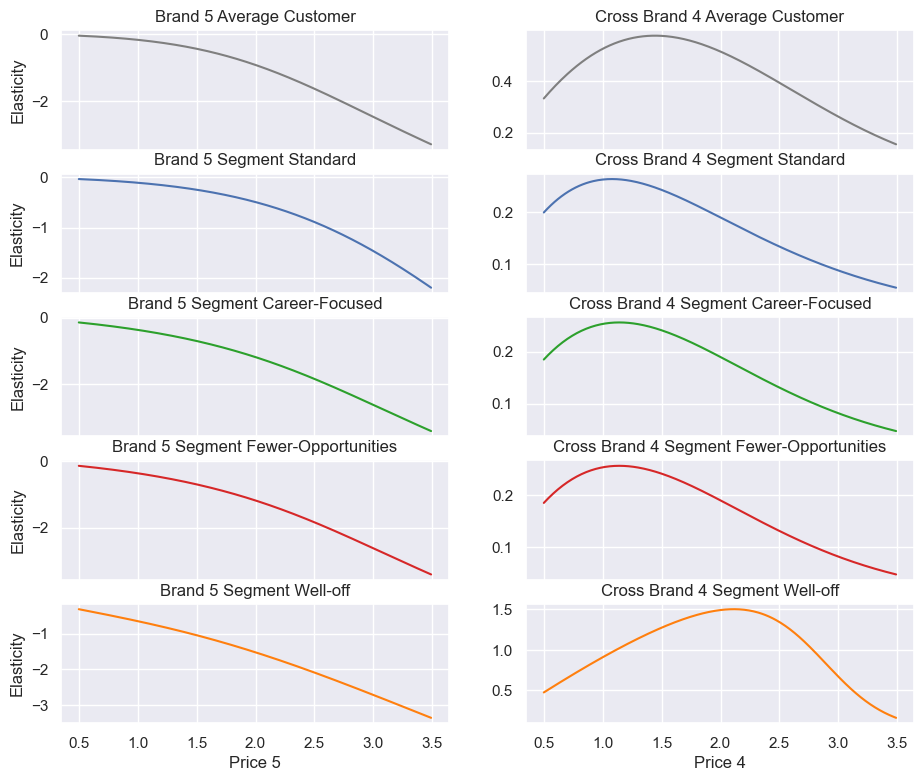

In [101]:
fig1, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(5, 2, figsize = (11, 9), sharex = True)
ax1[0].plot(price_range, own_price_elasticity_brand_5, 'tab:grey')
ax1[0].set_title('Brand 5 Average Customer')
ax1[0].set_ylabel('Elasticity')
ax1[1].plot(price_range, brand5_cross_brand4_price_elasticity, 'tab:grey')
ax1[1].set_title('Cross Brand 4 Average Customer')


ax2[0].plot(price_range, own_price_elasticity_brand_5_s0)
ax2[0].set_title('Brand 5 Segment Standard')
ax2[0].set_ylabel('Elasticity')
ax2[1].plot(price_range, brand5_cross_brand4_price_elasticity_s0)
ax2[1].set_title('Cross Brand 4 Segment Standard')

ax3[0].plot(price_range, own_price_elasticity_brand_5_s1, 'tab:green')
ax3[0].set_title('Brand 5 Segment Career-Focused')
ax3[0].set_ylabel('Elasticity')
ax3[1].plot(price_range, brand5_cross_brand4_price_elasticity_s1, 'tab:green')
ax3[1].set_title('Cross Brand 4 Segment Career-Focused')

ax4[0].plot(price_range, own_price_elasticity_brand_5_s2, 'tab:red')
ax4[0].set_title('Brand 5 Segment Fewer-Opportunities')
ax4[0].set_ylabel('Elasticity')
ax4[1].plot(price_range, brand5_cross_brand4_price_elasticity_s2, 'tab:red')
ax4[1].set_title('Cross Brand 4 Segment Fewer-Opportunities')

ax5[0].plot(price_range, own_price_elasticity_brand_5_s3, 'tab:orange')
ax5[0].set_title('Brand 5 Segment Well-off')
ax5[0].set_xlabel('Price 5')
ax5[0].set_ylabel('Elasticity')
ax5[1].plot(price_range, brand5_cross_brand4_price_elasticity_s3, 'tab:orange')
ax5[1].set_title('Cross Brand 4 Segment Well-off')
ax5[1].set_xlabel('Price 4')

### Price Elasticity of Purchase Quantity ###

In [102]:
df_purchase_quantity = df_pa[df_pa['Incidence'] == 1]
df_purchase_quantity.head()

,ID,Day,Incidence,Brand,Quantity,Last_Inc_Brand,Last_Inc_Quantity,Price_1,Price_2,Price_3,...,Age,Education,Income,Occupation,Settlement size,Segment,Segment_0,Segment_1,Segment_2,Segment_3
6,200000001,28,1,2,2,0,0,1.50,1.90,1.99,...,47,1,110866,1,0,0,True,False,False,False
11,200000001,58,1,5,1,0,0,1.39,1.90,1.91,...,47,1,110866,1,0,0,True,False,False,False
19,200000001,110,1,1,2,0,0,1.47,1.90,1.99,...,47,1,110866,1,0,0,True,False,False,False
24,200000001,142,1,4,1,0,0,1.21,1.35,1.99,...,47,1,110866,1,0,0,True,False,False,False
29,200000001,183,1,2,3,0,0,1.46,1.88,1.97,...,47,1,110866,1,0,0,True,False,False,False


In [103]:
df_purchase_quantity = pd.get_dummies(df_purchase_quantity, columns = ['Brand'], prefix = 'Brand', prefix_sep = '_')
df_purchase_quantity.describe()

,ID,Day,Incidence,Quantity,Last_Inc_Brand,Last_Inc_Quantity,Price_1,Price_2,Price_3,Price_4,...,Promotion_4,Promotion_5,Sex,Marital status,Age,Education,Income,Occupation,Settlement size,Segment
count,1.463800e+04,14638.000000,14638.0,14638.000000,14638.000000,14638.000000,14638.000000,14638.000000,14638.000000,14638.000000,...,14638.000000,14638.000000,14638.000000,14638.000000,14638.000000,14638.000000,14638.000000,14638.000000,14638.000000,14638.000000
mean,2.000003e+08,359.607597,1.0,2.774559,1.535251,0.406955,1.384559,1.764717,2.006694,2.159658,...,0.128091,0.045430,0.357289,0.385162,40.346905,1.151045,126706.452043,0.845471,0.797513,1.255431
std,1.423786e+02,205.346253,0.0,1.796736,2.060858,0.491283,0.090944,0.181667,0.046200,0.093253,...,0.334203,0.208252,0.479217,0.486650,12.346284,0.634625,39935.109358,0.633840,0.810358,1.159187
min,2.000000e+08,1.000000,1.0,1.000000,0.000000,0.000000,1.100000,1.260000,1.870000,1.760000,...,0.000000,0.000000,0.000000,0.000000,18.000000,0.000000,38247.000000,0.000000,0.000000,0.000000
25%,2.000001e+08,175.000000,1.0,2.000000,0.000000,0.000000,1.340000,1.570000,1.970000,2.120000,...,0.000000,0.000000,0.000000,0.000000,31.000000,1.000000,102723.000000,0.000000,0.000000,0.000000
50%,2.000003e+08,355.000000,1.0,2.000000,0.000000,0.000000,1.390000,1.880000,2.010000,2.180000,...,0.000000,0.000000,0.000000,0.000000,37.000000,1.000000,122895.000000,1.000000,1.000000,1.000000
75%,2.000004e+08,532.000000,1.0,3.000000,4.000000,1.000000,1.470000,1.890000,2.060000,2.240000,...,0.000000,0.000000,1.000000,1.000000,49.000000,2.000000,147967.000000,1.000000,1.000000,2.000000
max,2.000005e+08,727.000000,1.0,15.000000,5.000000,1.000000,1.590000,1.900000,2.140000,2.260000,...,1.000000,1.000000,1.000000,1.000000,75.000000,3.000000,309364.000000,2.000000,2.000000,3.000000


In [104]:
df_purchase_quantity.columns.values

array(['ID', 'Day', 'Incidence', 'Quantity', 'Last_Inc_Brand',
       'Last_Inc_Quantity', 'Price_1', 'Price_2', 'Price_3', 'Price_4',
       'Price_5', 'Promotion_1', 'Promotion_2', 'Promotion_3',
       'Promotion_4', 'Promotion_5', 'Sex', 'Marital status', 'Age',
       'Education', 'Income', 'Occupation', 'Settlement size', 'Segment',
       'Segment_0', 'Segment_1', 'Segment_2', 'Segment_3', 'Brand_1',
       'Brand_2', 'Brand_3', 'Brand_4', 'Brand_5'], dtype=object)

In [105]:
df_purchase_quantity['Price_Incidence'] = (df_purchase_quantity['Brand_1'] * df_purchase_quantity['Price_1'] +
                                           df_purchase_quantity['Brand_2'] * df_purchase_quantity['Price_2'] +
                                           df_purchase_quantity['Brand_3'] * df_purchase_quantity['Price_3'] +
                                           df_purchase_quantity['Brand_4'] * df_purchase_quantity['Price_4'] +
                                           df_purchase_quantity['Brand_5'] * df_purchase_quantity['Price_5'])

In [106]:
df_purchase_quantity['Promotion_Incidence'] = (df_purchase_quantity['Brand_1'] * df_purchase_quantity['Promotion_1'] +
                                               df_purchase_quantity['Brand_2'] * df_purchase_quantity['Promotion_2'] +
                                               df_purchase_quantity['Brand_3'] * df_purchase_quantity['Promotion_3'] +
                                               df_purchase_quantity['Brand_4'] * df_purchase_quantity['Promotion_4'] +
                                                df_purchase_quantity['Brand_5'] * df_purchase_quantity['Promotion_5'])

In [107]:
X = df_purchase_quantity[['Price_Incidence', 'Promotion_Incidence']]
X

,Price_Incidence,Promotion_Incidence
6,1.90,0
11,2.62,1
19,1.47,0
24,2.16,0
29,1.88,0
52,1.90,1
79,1.89,0
80,1.51,1
97,2.79,0
101,2.09,0


In [108]:
Y = df_purchase_quantity['Quantity']
Y.head()

6     2
11    1
19    2
24    1
29    3
Name: Quantity, dtype: int64

In [109]:
model_quantity = LinearRegression()
model_quantity.fit(X, Y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [110]:
model_quantity.coef_

array([-0.8173651 , -0.10504673])

### Price Elasticity Estimation

In [111]:
df_price_elasticity_quantity = pd.DataFrame(index = np.arange(price_range.size))
df_price_elasticity_quantity['Price_Incidence'] = price_range
df_price_elasticity_quantity['Promotion_Incidence'] = 1

In [112]:
beta_quantity = model_quantity.coef_[0]
beta_quantity

np.float64(-0.817365101668505)

In [113]:
predict_quantity = model_quantity.predict(df_price_elasticity_quantity)

In [114]:
price_elasticity_quantity_promotion_yes = beta_quantity * price_range / predict_quantity

In [115]:
df_price_elasticities['PE_Quantity_Promotion_1'] = price_elasticity_quantity_promotion_yes
df_price_elasticities

,Price_Point,Mean_PE,PE_Segment_0,PE_Segment_1,PE_Segment2,PE_Segment_3,Elasticity_Promotion_1,Elasticity_Promotion_0,Brand_5,Brand_5_Cross_Brand_4,Brand 5 S0,Brand_5_Cross_Brand_4_S0,Brand 5 S1,Brand_5_Cross_Brand_4_S1,Brand 5 S2,Brand_5_Cross_Brand_4_S2,Brand 5 S3,Brand_5_Cross_Brand_4_S3,PE_Quantity_Promotion_1
0,0.50,-0.096437,-0.068897,-0.177530,-0.095463,-0.159093,-0.125715,-0.195620,-0.049055,0.332011,-0.035731,0.199389,-0.146445,0.184847,-0.146442,0.184834,-0.316398,0.474975,-0.102157
1,0.51,-0.100506,-0.071950,-0.183530,-0.099774,-0.164047,-0.129830,-0.201741,-0.050616,0.337287,-0.036754,0.201845,-0.150059,0.187263,-0.150057,0.187249,-0.322783,0.484118,-0.104413
2,0.52,-0.104703,-0.075107,-0.189651,-0.104234,-0.169084,-0.134025,-0.207964,-0.052206,0.342506,-0.037792,0.204246,-0.153704,0.189631,-0.153701,0.189617,-0.329176,0.493246,-0.106679
3,0.53,-0.109030,-0.078370,-0.195894,-0.108849,-0.174206,-0.138299,-0.214290,-0.053826,0.347668,-0.038845,0.206592,-0.157379,0.191952,-0.157376,0.191938,-0.335577,0.502357,-0.108954
4,0.54,-0.113490,-0.081743,-0.202260,-0.113621,-0.179413,-0.142655,-0.220720,-0.055477,0.352773,-0.039913,0.208883,-0.161085,0.194227,-0.161082,0.194212,-0.341986,0.511452,-0.111238
5,0.55,-0.118087,-0.085230,-0.208752,-0.118556,-0.184705,-0.147092,-0.227255,-0.057158,0.357820,-0.040996,0.211120,-0.164822,0.196455,-0.164820,0.196440,-0.348404,0.520531,-0.113532
6,0.56,-0.122824,-0.088832,-0.215369,-0.123658,-0.190083,-0.151612,-0.233896,-0.058870,0.362809,-0.042095,0.213304,-0.168591,0.198636,-0.168588,0.198622,-0.354832,0.529592,-0.115836
7,0.57,-0.127704,-0.092554,-0.222115,-0.128931,-0.195549,-0.156216,-0.240644,-0.060614,0.367740,-0.043210,0.215435,-0.172391,0.200772,-0.172388,0.200757,-0.361268,0.538637,-0.118148
8,0.58,-0.132731,-0.096398,-0.228989,-0.134381,-0.201102,-0.160905,-0.247499,-0.062390,0.372614,-0.044341,0.217513,-0.176223,0.202862,-0.176220,0.202847,-0.367715,0.547665,-0.120471
9,0.59,-0.137908,-0.100369,-0.235994,-0.140012,-0.206745,-0.165679,-0.254461,-0.064199,0.377429,-0.045488,0.219538,-0.180086,0.204906,-0.180084,0.204892,-0.374171,0.556676,-0.122803


Text(0.5, 1.0, 'Price Elasticity of Quantity with Promotion')

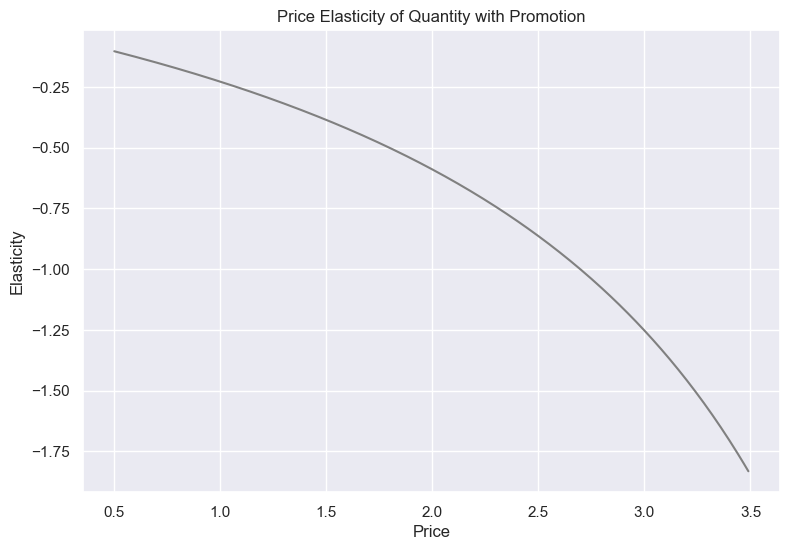

In [116]:
plt.figure(figsize = (9, 6))
plt.plot(price_range, price_elasticity_quantity_promotion_yes, color = 'grey')
plt.xlabel('Price')
plt.ylabel('Elasticity')
plt.title('Price Elasticity of Quantity with Promotion')

In [117]:
df_price_elasticity_quantity['Promotion_Incidence'] = 0

predict_quantity = model_quantity.predict(df_price_elasticity_quantity)

price_elasticity_quantity_promotion_no = beta_quantity * price_range / predict_quantity

df_price_elasticities['PE_Quantity_Promotion_0'] = price_elasticity_quantity_promotion_no
df_price_elasticities

,Price_Point,Mean_PE,PE_Segment_0,PE_Segment_1,PE_Segment2,PE_Segment_3,Elasticity_Promotion_1,Elasticity_Promotion_0,Brand_5,Brand_5_Cross_Brand_4,Brand 5 S0,Brand_5_Cross_Brand_4_S0,Brand 5 S1,Brand_5_Cross_Brand_4_S1,Brand 5 S2,Brand_5_Cross_Brand_4_S2,Brand 5 S3,Brand_5_Cross_Brand_4_S3,PE_Quantity_Promotion_1,PE_Quantity_Promotion_0
0,0.50,-0.096437,-0.068897,-0.177530,-0.095463,-0.159093,-0.125715,-0.195620,-0.049055,0.332011,-0.035731,0.199389,-0.146445,0.184847,-0.146442,0.184834,-0.316398,0.474975,-0.102157,-0.099543
1,0.51,-0.100506,-0.071950,-0.183530,-0.099774,-0.164047,-0.129830,-0.201741,-0.050616,0.337287,-0.036754,0.201845,-0.150059,0.187263,-0.150057,0.187249,-0.322783,0.484118,-0.104413,-0.101736
2,0.52,-0.104703,-0.075107,-0.189651,-0.104234,-0.169084,-0.134025,-0.207964,-0.052206,0.342506,-0.037792,0.204246,-0.153704,0.189631,-0.153701,0.189617,-0.329176,0.493246,-0.106679,-0.103939
3,0.53,-0.109030,-0.078370,-0.195894,-0.108849,-0.174206,-0.138299,-0.214290,-0.053826,0.347668,-0.038845,0.206592,-0.157379,0.191952,-0.157376,0.191938,-0.335577,0.502357,-0.108954,-0.106150
4,0.54,-0.113490,-0.081743,-0.202260,-0.113621,-0.179413,-0.142655,-0.220720,-0.055477,0.352773,-0.039913,0.208883,-0.161085,0.194227,-0.161082,0.194212,-0.341986,0.511452,-0.111238,-0.108369
5,0.55,-0.118087,-0.085230,-0.208752,-0.118556,-0.184705,-0.147092,-0.227255,-0.057158,0.357820,-0.040996,0.211120,-0.164822,0.196455,-0.164820,0.196440,-0.348404,0.520531,-0.113532,-0.110598
6,0.56,-0.122824,-0.088832,-0.215369,-0.123658,-0.190083,-0.151612,-0.233896,-0.058870,0.362809,-0.042095,0.213304,-0.168591,0.198636,-0.168588,0.198622,-0.354832,0.529592,-0.115836,-0.112836
7,0.57,-0.127704,-0.092554,-0.222115,-0.128931,-0.195549,-0.156216,-0.240644,-0.060614,0.367740,-0.043210,0.215435,-0.172391,0.200772,-0.172388,0.200757,-0.361268,0.538637,-0.118148,-0.115083
8,0.58,-0.132731,-0.096398,-0.228989,-0.134381,-0.201102,-0.160905,-0.247499,-0.062390,0.372614,-0.044341,0.217513,-0.176223,0.202862,-0.176220,0.202847,-0.367715,0.547665,-0.120471,-0.117339
9,0.59,-0.137908,-0.100369,-0.235994,-0.140012,-0.206745,-0.165679,-0.254461,-0.064199,0.377429,-0.045488,0.219538,-0.180086,0.204906,-0.180084,0.204892,-0.374171,0.556676,-0.122803,-0.119604


Text(0.5, 1.0, 'Price Elasticity of Purchase Quantity with Promotion')

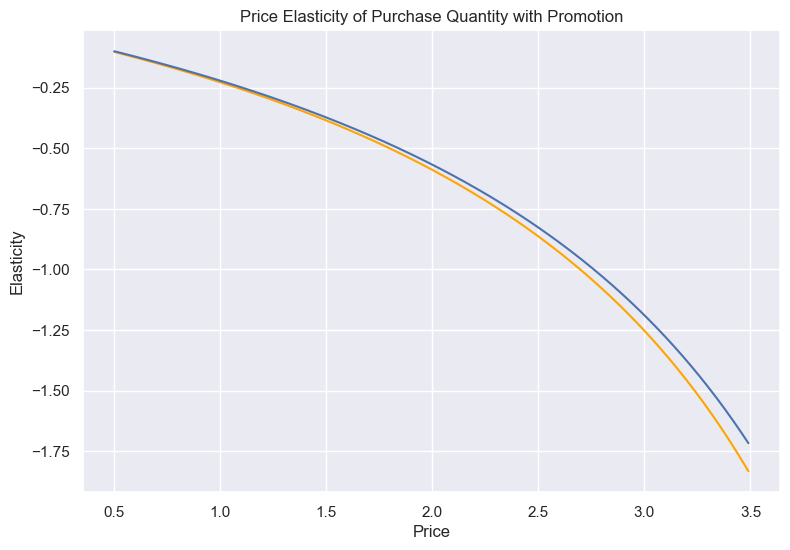

In [118]:
plt.figure(figsize = (9, 6))
plt.plot(price_range, price_elasticity_quantity_promotion_yes, color = 'orange')
plt.plot(price_range, price_elasticity_quantity_promotion_no)
plt.xlabel('Price')
plt.ylabel('Elasticity')
plt.title('Price Elasticity of Purchase Quantity with Promotion')